# MC

This notebook shows how to prgrametically run SWAT with pertubated inputs. It imports from `python_pipeline_scripts`.

## Load environment

In [3]:
import sys; sys.executable

'c:\\Program Files\\Python312\\python.exe'

In [4]:
from pathlib import Path
import sys
# Add project root to sys.path for imports
sys.path.insert(0, str(Path().resolve().parent))
from python_pipeline_scripts import utils, runner
from python_pipeline_scripts.provenance_report import write_provenance_reports

# Load config from config.yaml
config = utils.load_config(Path().resolve().parent / 'config' / 'config.yaml')

# Enable autoreload in Jupyter for live code updates
try:
    get_ipython().run_line_magic("load_ext", "autoreload")
    get_ipython().run_line_magic("autoreload", "1")
except NameError:
    pass  # Not in IPython/Jupyter


# this is were this notebook is located and from where relative paths will be resolved
import os
os.getcwd()

'c:\\Users\\Usuario\\OneDrive - UNIVERSIDAD DE HUELVA\\Granada\\TrabajoFM\\scripts\\Python_Pipeline_SWAT_Pascal\\swat_pipeline\\trabajoFM\\notebooks'

## monte carlo runs

In [5]:
# Ensure verbose logging for raster aggregation (even when cached)
from python_pipeline_scripts import utils
from pathlib import Path

cfg = utils.load_config(Path("../config/config.yaml"))
# Force INFO/DEBUG as you prefer
cfg.setdefault("logging", {})["level"] = "INFO"

# Initialize module loggers with this config BEFORE invoking the functions
utils.get_logger("python_pipeline_scripts.raster_agg", config=cfg)
utils.get_logger("python_pipeline_scripts.transforms.soil_chm", config=cfg)

# Now your call will emit lines like:
# "Reprojected (cached) -> ..." and "Clipped (cached) -> ..."


<Logger python_pipeline_scripts.transforms.soil_chm (INFO)>

In [6]:
# Input paths (run this cell before your main pipeline cell)

from pathlib import Path
from python_pipeline_scripts.provenance_report import build_upstream_inputs

def _resolve(p: str, base: Path) -> Path:
    pp = Path(p)
    return pp if pp.is_absolute() else (base / pp).resolve()

# ---------- CHM inputs ----------
script_dir = Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\script DIFFUSE loads - input .chm")
raster_folder = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil_ArcGIS_Ruben\ArcGIS _ base de suelo quimico _ ruben _ 30-05-25\raster\temp_rasters"
hru_zones_fp= r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Archivos de Cesar Ruben Fernandez De Villaran San Juan - swat_cubillas\cubillas_hru\Watershed\Shapes\hru1.shp"
output_gpkg = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil GEO_INFO_POOL\Input Data\Diffuse loads\Soil chemical composition\python calculated hru stats\hru_chem_stats.gpkg"

output_gpkg_p = _resolve(output_gpkg, script_dir)
raster_folder_p = _resolve(raster_folder, script_dir)
zones_fp_p = Path(hru_zones_fp)
manifest_file = Path(str(output_gpkg_p) + ".manifest.json")
chm_csv = str(output_gpkg_p).replace(".gpkg", ".csv")

# ---------- Point loads inputs ----------
point_script_dir = Path(r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\script POINT loads - input .dat")
pop_raster_folder = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil GEO_INFO_POOL\Input Data\Point loads\Population data\HIPGDAC-ES-v1.0.0\fgoerlich-HIPGDAC-ES-cd11f21\HIPGDAC-ES\1970-2021 copy"
subbasins_fp = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil GEO_INFO_POOL\SWaT outputs\Cubillas\shapes cubillas\Sub_basin.shp"
pop_output_gpkg = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil GEO_INFO_POOL\Input Data\Point loads\Population data\HIPGDAC-ES-v1.0.0\custom_aggregations\open_source\cubillas_population.gpkg"

pop_raster_folder_p = _resolve(pop_raster_folder, point_script_dir)
#subbasins_fp_p = _resolve(subbasins_fp, point_script_dir)
pop_output_gpkg_p = _resolve(pop_output_gpkg, point_script_dir)
point_csv = Path(str(pop_output_gpkg_p).replace(".gpkg", ".csv"))

# ---------- SWAT base + outputs ----------
base_txtinout = r"C:\SWAT\RSWAT\cubillas\cubillas_set_219_ruben\cubillas_BASE_set-219\BASE recreated from arcswat default\TxtInOut_1"
realizations_root = r"C:\SWAT\RSWAT\cubillas\mc_realizations"
results_root = r"C:\SWAT\RSWAT\cubillas\mc_results"

base_txtinout_p = Path(base_txtinout)
realizations_root_p = Path(realizations_root); realizations_root_p.mkdir(parents=True, exist_ok=True)
results_root_p = Path(results_root); results_root_p.mkdir(parents=True, exist_ok=True)

# ---------- Upstream inputs for provenance ----------
upstream_chm = build_upstream_inputs(
    raster_folder=raster_folder_p,
    pattern="*_rediam.tif",
    zones_fp=zones_fp_p,
    gpkg_path=output_gpkg_p,
    csv_path=Path(chm_csv),
)
upstream_point = [point_csv]
upstream = list({Path(p) for p in (upstream_chm + upstream_point)})


# ----------- config ------------------------------

cfg = utils.load_config(Path("../config/config.yaml"))


# ---------- Quick sanity prints ----------
print("repo wide config:", cfg)
print("CHM GPKG:", output_gpkg_p)
print("CHM CSV:", chm_csv)
print("Point GPKG:", pop_output_gpkg_p)
print("Point CSV:", point_csv)
print("Base TxtInOut:", base_txtinout_p)
print("Realizations root:", realizations_root_p)
print("Results root:", results_root_p)
print("Manifest (CHM):", manifest_file)


repo wide config: {'logging': {'level': 'INFO', 'log_dir': 'logs', 'file': 'pipeline.log', 'format': '%(asctime)s | %(levelname)s | %(name)s | %(message)s'}, 'paths': {'project_root': '..', 'data_root': 'data', 'outputs_root': 'outputs', 'base_txtinout': 'C:\\SWAT\\RSWAT\\cubillas\\cubillas_set_219_ruben\\cubillas_BASE_set-219\\BASE recreated from arcswat default\\TxtInOut_1', 'swat_executable': 'C:\\SWAT\\ArcSWAT\\swat_64rel.exe'}, 'input_groups': {'baseline': {'description': 'Base input data set (recreated)', 'folder': 'C:\\SWAT\\RSWAT\\cubillas\\cubillas_set_219_ruben\\cubillas_BASE_set-219\\BASE recreated from arcswat default\\TxtInOut_1'}, 'urban_expansion_2030': {'description': 'Urban expansion scenario for 2030', 'folder': 'data/input_groups/urban_expansion_2030'}, 'climate_rcp45': {'description': 'Climate RCP4.5 scenario', 'folder': 'data/input_groups/climate_rcp45'}}, 'reproducibility': {'random_seed': 12345, 'change_sets': [{'name': 'example_change', 'applies_to_group': 'base

## Run input data transformation pipeline (or load from cache)

In [7]:
from pathlib import Path
from typing import List

def find_files_with_string(base_path: str, search_str: str, prefix: str = "", remove_substring: str = "") -> List[str]:
    """
    Look for files in base_path whose names contain search_str.
    Return a list of file names with prefix prepended, and with remove_substring removed from the name if present.

    Parameters
    ----------
    base_path : str
        The path to search in.
    search_str : str
        The substring to look for in file names (case-sensitive).
    prefix : str, optional
        Prefix to prepend to each matching file name.
    remove_substring : str, optional
        Substring to remove from each matching file name before returning.

    Returns
    -------
    List[str]
        List of matching file names with prefix, and with remove_substring removed.
    """
    base = Path(base_path)
    if not base.is_dir():
        raise ValueError(f"{base_path} is not a valid directory")

    matches = []
    for entry in base.iterdir():
        if entry.is_file() and search_str in entry.name:
            name = entry.name
            if remove_substring:
                name = name.replace(remove_substring, "")
            matches.append(prefix + name)

    return matches


path_to_rasters = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil_ArcGIS_Ruben\ArcGIS _ base de suelo quimico _ ruben _ 30-05-25\raster\temp_rasters"

P_raster_interpolation = find_files_with_string(path_to_rasters, "P_", "mean_", remove_substring = ".tif")[0]
N_raster_interpolation = find_files_with_string(path_to_rasters, "N_", "mean_", remove_substring = ".tif")[0]
N_raster_interpolation, P_raster_interpolation

('mean_N_prediction_best_according_weight_bias_accuracy_wc_error_resample',
 'mean_P_prediction_best_according_weight_bias_accuracy_wc_error_resample')

In [8]:
# Inputs + aggregator with rebuild flags (CHM + Point); logs all decisions.
from pathlib import Path
from python_pipeline_scripts import utils
from python_pipeline_scripts.raster_agg import  rasterZonalAggregationToGPKG
from python_pipeline_scripts.transforms.soil_chm import read_n_p_means_from_csv_to_df
from python_pipeline_scripts.transforms.point_dat import read_population_by_subbasin_csv_to_df
from python_pipeline_scripts.transforms.point_utils import normalize_point_year_columns
from python_pipeline_scripts.provenance_report import build_upstream_inputs

# Flags: set True to force (re)create CSVs; set False to use cached CSVs if present
REBUILD_CHM_CSV = False
REBUILD_POINT_CSV = False

# Ensure module loggers are initialized with your config so cached actions are printed
utils.get_logger("python_pipeline_scripts.raster_agg", config=cfg)
utils.get_logger("python_pipeline_scripts.transforms.soil_chm", config=cfg)
log = utils.get_logger("notebook.inputs", config=cfg)

def ensure_chm_csv(*, chm_csv: str, raster_folder_p: Path, zones_fp_p: Path, output_gpkg_p: Path, rebuild: bool):
    chm_csv_p = Path(chm_csv)
    if rebuild or not chm_csv_p.exists():
        log.info("CHM CSV missing or rebuild=True; running rasterZonalAggregationToGPKG")
        _ = rasterZonalAggregationToGPKG( #raster_zonal_aggregation_to_gpkg_and_csv(   #raster_zonal_aggregation_to_gpkg(
            raster_folder=raster_folder_p,
            zones_fp=zones_fp_p,
            zone_field="HRU_GIS",
            label_field="OBJECTID",
            output_gpkg=output_gpkg_p,
            files_end_with="_resample.tif",
            stat_operation="mean",
            raster_alias="full_name",
            zone_meaning="HRU",
            overwrite_cache=rebuild,
            #write_manifest=True,
            #config=cfg,
        )
        log.info("CHM CSV ready: %s", chm_csv_p)
    else:
        log.info("Using cached CHM CSV: %s", chm_csv_p)
    return chm_csv_p

def ensure_point_csv(*, point_csv: Path, pop_raster_folder_p: Path, subbasins_fp: Path, pop_output_gpkg_p: Path, rebuild: bool):
    if rebuild or not point_csv.exists():
        try:
            from python_pipeline_scripts.TEMP_point_dat_insparation import subbasinPopulationAggregationToGPKG
            log.info("Point CSV missing or rebuild=True; building population GPKG/CSV")
            _ = subbasinPopulationAggregationToGPKG(
                raster_folder=str(pop_raster_folder_p),
                sub_basin_fp=str(subbasins_fp),
                zone_field="GRIDCODE",
                output_gpkg=str(pop_output_gpkg_p),
                overwrite_cache=rebuild,
            )
            if not point_csv.exists():
                raise FileNotFoundError(f"Builder ran but CSV still missing: {point_csv}")
            log.info("Point CSV ready: %s", point_csv)
        except Exception as e:
            log.error("Failed to build point CSV automatically: %s", e)
            raise
    else:
        log.info("Using cached Point CSV: %s", point_csv)
    return point_csv

# Ensure CSVs exist (or rebuild if flags set)
chm_csv_p = ensure_chm_csv(
    chm_csv=chm_csv,
    raster_folder_p=raster_folder_p,
    zones_fp_p=zones_fp_p,
    output_gpkg_p=output_gpkg_p,
    rebuild=REBUILD_CHM_CSV,
)
point_csv_p = ensure_point_csv(
    point_csv=point_csv,
    pop_raster_folder_p=pop_raster_folder_p,
    subbasins_fp=subbasins_fp,
    pop_output_gpkg_p=pop_output_gpkg_p,
    rebuild=REBUILD_POINT_CSV,
)

# Upstream inputs for provenance
upstream_chm = build_upstream_inputs(
    raster_folder=raster_folder_p,
    pattern="*_rediam.tif",
    zones_fp=zones_fp_p,
    gpkg_path=output_gpkg_p,
    csv_path=chm_csv_p,
)
upstream_point = [point_csv_p]
upstream = list({Path(p) for p in (upstream_chm + upstream_point)})

# Aggregator: logs will show if cached/rebuilt
aggregator = lambda: {
    "chm": read_n_p_means_from_csv_to_df(
        str(chm_csv_p),
        id_col="HRU_GIS",
        n_col=N_raster_interpolation,
        #n_col="N_prediction_best_according_weight_bias_accuracy_wc_error_resample",
        p_col=P_raster_interpolation,
    ),
    "point": normalize_point_year_columns(
        read_population_by_subbasin_csv_to_df(point_csv_p, id_col="GRIDCODE", sep=";"),
        id_col="GRIDCODE",
        debug=False,
    ),
}


2026-04-24 11:13:43,415 | INFO | notebook.inputs | Using cached CHM CSV: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil GEO_INFO_POOL\Input Data\Diffuse loads\Soil chemical composition\python calculated hru stats\hru_chem_stats.csv
2026-04-24 11:13:43,418 | INFO | notebook.inputs | Using cached Point CSV: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\Genil GEO_INFO_POOL\Input Data\Point loads\Population data\HIPGDAC-ES-v1.0.0\custom_aggregations\open_source\cubillas_population.csv


### Compare global error/uncerteinty metrics from leave-one-out cross-validation CSV

In [9]:
import pandas as pd
import numpy as np
from pathlib import Path

def calculate_uncertainty_measures(csv_path, value_col='Measured', pred_col='Predicted', 
                                   filter_zeros=True, epsilon=1e-10):
    """
    Calculate global uncertainty measures from leave-one-out cross-validation CSV.

    Parameters
    ----------
    csv_path : str
        Path to the CSV file containing measured and predicted values.
    value_col : str
        Column name for observed values (default: 'Measured').
    pred_col : str
        Column name for predicted values (default: 'Predicted').
    filter_zeros : bool
        If True, remove rows where observed value is 0 (default: True).
    epsilon : float
        Small value to avoid division by zero in relative error calculation.

    Returns
    -------
    dict
        Dictionary with global uncertainty metrics.
    """
    # Load CSV
    df = pd.read_csv(csv_path)
    
    # Optionally remove rows where measured = 0
    if filter_zeros:
        df = df[df[value_col] != 0].copy()
    
    if df.empty:
        raise ValueError("No valid rows remain after filtering zeros.")
    
    # Compute relative errors (relative to measured value)
    rel_error = (df[pred_col] - df[value_col]) / (df[value_col] + epsilon)
    abs_rel_error = np.abs(rel_error)
    
    # Compute RMSE-based metrics
    rmse = np.sqrt(np.mean((df[pred_col] - df[value_col])**2))
    obs_range = df[value_col].max() - df[value_col].min()
    obs_mean = df[value_col].mean()
    
    # Compute standard metrics
    metrics = {}
    metrics['File_Name'] = Path(csv_path).name
    
    metrics['RMSE'] = rmse
    metrics['NRMSE_Range'] = rmse / obs_range if abs(obs_range) > epsilon else np.nan
    metrics['NRMSE_Mean'] = rmse / obs_mean if abs(obs_mean) > epsilon else np.nan
    metrics['Mean_Relative_Error'] = np.mean(rel_error)
    metrics['Mean_Absolute_Relative_Error'] = np.mean(abs_rel_error)
    metrics['Median_Relative_Error'] = np.median(rel_error)
    metrics['Median_Absolute_Relative_Error'] = np.median(abs_rel_error)
    
    metrics['P75_Relative_Error'] = np.percentile(rel_error, 75)
    metrics['P75_Absolute_Relative_Error'] = np.percentile(abs_rel_error, 75)
    
    metrics['P90_Relative_Error'] = np.percentile(rel_error, 90)
    metrics['P90_Absolute_Relative_Error'] = np.percentile(abs_rel_error, 90)
    metrics['Std_Relative_Error'] = np.std(rel_error)
    metrics['Count'] = len(df)
    metrics['Trailing_New_Line'] = "\n"
    
    return metrics

# ------------------------------
# Example usage:


def print_uncertainty_results(results):
    for k, v in results.items():
        if k == 'Trailing_New_Line':
            print(v, end="")
        elif isinstance(v, str):
            print(f"{k}: {v}")
        else:
            print(f"{k}: {v:.4f}")


# original P REDIAM interpolation
csv_file_2_point_5 = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\P_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv"
results = calculate_uncertainty_measures(csv_file_2_point_5, filter_zeros=True)
print_uncertainty_results(results)


# # first wrong P REDIAM + LUCAS interpolation
# csv_file_2 = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\P_LUCAS_AND_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv"
# results = calculate_uncertainty_measures(csv_file_2, filter_zeros=True)
# print_uncertainty_results(results)

# # second correctly harmonized P REDIAM + LUCAS interpolation
# csv_file_2_point_2 = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TRABAJ~1\scripts\PYTHON~1\SWAT_P~1\TRABAJ~1\INPUT_~1\SOIL_I~1\P_LUCA~2.CSV"  # harmonized version
# results = calculate_uncertainty_measures(csv_file_2_point_2, filter_zeros=True)
# print_uncertainty_results(results)


# original N REDIAM interpolation
csv_file_1_point_5 = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\N_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv"
results = calculate_uncertainty_measures(csv_file_1_point_5, filter_zeros=True)
print_uncertainty_results(results)

# # first wrong N REDIAM + LUCAS interpolation
# csv_file_1 = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\N_LUCAS_AND_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv"
# results = calculate_uncertainty_measures(csv_file_1, filter_zeros=True)
# print_uncertainty_results(results)

# # second correctly harmonized N REDIAM + LUCAS interpolation
# csv_file_1_point_2 = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TRABAJ~1\scripts\PYTHON~1\SWAT_P~1\TRABAJ~1\INPUT_~1\SOIL_I~1\N_LUCA~2.CSV"  # harmonized version
# results = calculate_uncertainty_measures(csv_file_1_point_2, filter_zeros=True)
# print_uncertainty_results(results)



File_Name: P_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv
RMSE: 28.6732
NRMSE_Range: 0.1491
NRMSE_Mean: 1.0040
Mean_Relative_Error: 24.8744
Mean_Absolute_Relative_Error: 25.2558
Median_Relative_Error: 0.2588
Median_Absolute_Relative_Error: 0.6465
P75_Relative_Error: 2.0311
P75_Absolute_Relative_Error: 2.0311
P90_Relative_Error: 6.7219
P90_Absolute_Relative_Error: 6.7219
Std_Relative_Error: 166.2357
Count: 255.0000

File_Name: N_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv
RMSE: 0.3821
NRMSE_Range: 0.0646
NRMSE_Mean: 1.6072
Mean_Relative_Error: 0.7002
Mean_Absolute_Relative_Error: 0.9509
Median_Relative_Error: 0.2434
Median_Absolute_Relative_Error: 0.4696
P75_Relative_Error: 0.9904
P75_Absolute_Relative_Error: 0.9904
P90_Relative_Error: 1.9578
P90_Absolute_Relative_Error: 1.9578
Std_Relative_Error: 1.8656
Count: 326.0000




=== P soil interpolation ===
Field-structure table


,Dataset,Source,Count,Min,Q1,Mean,Median,Q3,Max,IQR,CV,Hotspot_Attenuation_vs_Observed_Max
0,P soil interpolation,Observed points,255,0.0100,6.8800,28.5582,17.5000,38.9650,192.3600,32.0850,1.0899,1.0000
1,P soil interpolation,Interpolated raster (full domain),68491332,-1.0895,12.4658,22.1504,21.0870,30.6972,76.8871,18.2314,0.5969,NaN
2,P soil interpolation,Interpolated raster (HRU zones),7470078,0.0000,0.0000,6.3363,3.6908,11.2648,26.1734,11.2648,1.1751,NaN
3,P soil interpolation,Final HRU averages,878,3.4219,6.0256,11.8921,11.2134,16.7493,26.1189,10.7237,0.5446,0.1358


Leave-one-out error table


,Dataset,Count,Bias,MAE,RMSE,Median_Absolute_Relative_Error,P75_Absolute_Relative_Error,P90_Absolute_Relative_Error,Share_Within_25pct,Share_Within_50pct,Share_Within_Factor_2,Underprediction_Share,Overprediction_Share,sMAPE,Pearson_r,ASE,Coverage_95pct_pct,RMSSE
0,P soil interpolation,255,-4.1336,19.2837,28.6732,0.6465,2.0311,6.7219,18.0392,36.0784,43.5294,41.9608,58.0392,0.8051,0.4124,26.6856,92.9412,1.0738


REDIAM vs REDIAM + LUCAS comparison


,Dataset,Count,Bias,MAE,RMSE,Median_Absolute_Relative_Error,P75_Absolute_Relative_Error,P90_Absolute_Relative_Error,Share_Within_25pct,Share_Within_50pct,Share_Within_Factor_2,Underprediction_Share,Overprediction_Share,sMAPE,Pearson_r,ASE,Coverage_95pct_pct,RMSSE
0,P soil interpolation | REDIAM,255,-4.1336,19.2837,28.6732,0.6465,2.0311,6.7219,18.0392,36.0784,43.5294,41.9608,58.0392,0.8051,0.4124,26.6856,92.9412,1.0738
1,P soil interpolation | REDIAM + LUCAS,351,-12.3158,73.0410,115.9714,0.8047,2.8738,8.1730,18.2336,32.7635,40.7407,38.7464,61.2536,0.8786,0.4004,115.5106,94.0171,1.0092


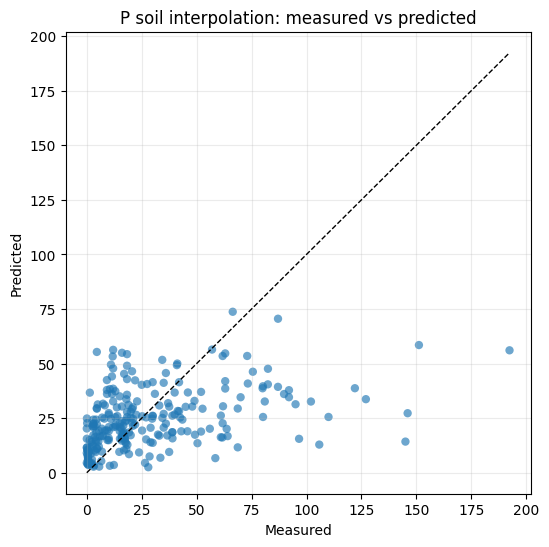


=== N soil interpolation ===
Field-structure table


,Dataset,Source,Count,Min,Q1,Mean,Median,Q3,Max,IQR,CV,Hotspot_Attenuation_vs_Observed_Max
0,N soil interpolation,Observed points,326,0.0200,0.0800,0.2378,0.1200,0.1900,5.9400,0.1100,1.9706,1.0000
1,N soil interpolation,Interpolated raster (full domain),68491332,0.0000,0.1112,0.2169,0.1618,0.2500,1.7711,0.1388,0.9159,NaN
2,N soil interpolation,Interpolated raster (HRU zones),7470078,0.0000,0.0000,0.0893,0.1060,0.1562,0.4963,0.1562,0.9841,NaN
3,N soil interpolation,Final HRU averages,878,0.0958,0.1294,0.1623,0.1591,0.1920,0.3366,0.0626,0.2681,0.0567


Leave-one-out error table


,Dataset,Count,Bias,MAE,RMSE,Median_Absolute_Relative_Error,P75_Absolute_Relative_Error,P90_Absolute_Relative_Error,Share_Within_25pct,Share_Within_50pct,Share_Within_Factor_2,Underprediction_Share,Overprediction_Share,sMAPE,Pearson_r,ASE,Coverage_95pct_pct,RMSSE
0,N soil interpolation,326,-0.003,0.1474,0.3821,0.4696,0.9904,1.9578,28.8344,53.3742,66.8712,35.5828,64.4172,0.5421,0.579,0.4702,97.8528,0.8197


REDIAM vs REDIAM + LUCAS comparison


,Dataset,Count,Bias,MAE,RMSE,Median_Absolute_Relative_Error,P75_Absolute_Relative_Error,P90_Absolute_Relative_Error,Share_Within_25pct,Share_Within_50pct,Share_Within_Factor_2,Underprediction_Share,Overprediction_Share,sMAPE,Pearson_r,ASE,Coverage_95pct_pct,RMSSE
0,N soil interpolation | REDIAM,326,-0.003,0.1474,0.3821,0.4696,0.9904,1.9578,28.8344,53.3742,66.8712,35.5828,64.4172,0.5421,0.5790,0.4702,97.8528,0.8197
1,N soil interpolation | REDIAM + LUCAS,429,-40.632,1279.2276,3333.2365,0.4377,0.8681,1.8857,29.8368,55.4779,70.1632,37.7622,62.0047,0.5138,0.5893,3732.3605,97.4359,0.8975


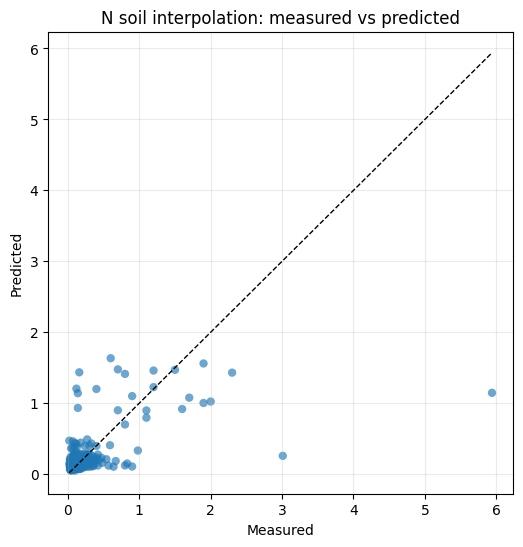

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from IPython.display import display
import rasterio
import rasterio.mask
import fiona
import warnings

def _load_cv_diagnostics(csv_path, value_col='Measured', pred_col='Predicted', filter_zeros=True, epsilon=1e-10):
    df = pd.read_csv(csv_path)
    if filter_zeros:
        df = df[df[value_col] != 0].copy()
    if df.empty:
        raise ValueError('No valid rows remain after filtering zeros.')
    df['Error'] = df[pred_col] - df[value_col]
    df['AbsError'] = df['Error'].abs()
    df['RelError'] = df['Error'] / (df[value_col] + epsilon)
    df['AbsRelError'] = df['RelError'].abs()
    df['Ratio_Predicted_to_Measured'] = df[pred_col] / (df[value_col] + epsilon)
    df['sMAPE'] = 2.0 * df['AbsError'] / (df[pred_col].abs() + df[value_col].abs() + epsilon)
    return df

def _read_hru_field(hru_csv_path, hru_value_col):
    hru_df = pd.read_csv(hru_csv_path, sep=';')
    if hru_value_col not in hru_df.columns:
        raise KeyError(f'Column {hru_value_col!r} not found in {Path(hru_csv_path).name}')
    return hru_df[hru_value_col].astype(float)

def _series_structure(values, dataset_label, source_label, epsilon=1e-10):
    series = pd.Series(values, dtype=float).dropna()
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    return {
        'Dataset': dataset_label,
        'Source': source_label,
        'Count': int(series.size),
        'Min': float(series.min()),
        'Q1': float(q1),
        'Mean': float(series.mean()),
        'Median': float(series.median()),
        'Q3': float(q3),
        'Max': float(series.max()),
        'IQR': float(q3 - q1),
        'CV': float(series.std(ddof=0) / (series.mean() + epsilon)),
    }

def _load_raster_stats(raster_path, dataset_label, source_label, epsilon=1e-10):
    """Load full raster and compute statistics for non-null values."""
    try:
        with rasterio.open(raster_path) as src:
            data = src.read(1)
            nodata = src.nodata
            # Extract non-null values
            if nodata is not None:
                values = data[~np.isnan(data) & (data != nodata)]
            else:
                values = data[~np.isnan(data)]
            if len(values) == 0:
                warnings.warn(f"No valid pixels in {Path(raster_path).name}; skipping raster stats")
                return None
        return _series_structure(values, dataset_label, source_label, epsilon=epsilon)
    except Exception as e:
        warnings.warn(f"Error loading raster {Path(raster_path).name}: {e}")
        return None

def _load_raster_stats_clipped(raster_path, shapes_path, dataset_label, source_label, epsilon=1e-10):
    """Load raster clipped to shapefile geometries and compute statistics."""
    try:
        with fiona.open(shapes_path, encoding='utf-8') as shapes:
            features = [feature['geometry'] for feature in shapes]
        if not features:
            warnings.warn(f"No geometries found in {Path(shapes_path).name}")
            return None
        with rasterio.open(raster_path) as src:
            try:
                masked_array, _ = rasterio.mask.mask(src, features, crop=True)
            except ValueError as e:
                warnings.warn(f"Clipping failed (no intersection?): {e}; skipping clipped raster stats")
                return None
            data = masked_array[0]
            nodata = src.nodata
            if nodata is not None:
                values = data[~np.isnan(data) & (data != nodata)]
            else:
                values = data[~np.isnan(data)]
            if len(values) == 0:
                warnings.warn(f"No valid pixels after clipping {Path(raster_path).name}")
                return None
        return _series_structure(values, dataset_label, source_label, epsilon=epsilon)
    except Exception as e:
        warnings.warn(f"Error clipping raster {Path(raster_path).name}: {e}")
        return None

def _error_summary(cv_df, dataset_label, value_col='Measured', pred_col='Predicted', epsilon=1e-10):
    ratio = cv_df[pred_col] / (cv_df[value_col] + epsilon)
    summary = {
        'Dataset': dataset_label,
        'Count': int(len(cv_df)),
        'Bias': float(cv_df['Error'].mean()),
        'MAE': float(cv_df['AbsError'].mean()),
        'RMSE': float(np.sqrt(np.mean(cv_df['Error'] ** 2))),
        'Median_Absolute_Relative_Error': float(cv_df['AbsRelError'].median()),
        'P75_Absolute_Relative_Error': float(cv_df['AbsRelError'].quantile(0.75)),
        'P90_Absolute_Relative_Error': float(cv_df['AbsRelError'].quantile(0.90)),
        'Share_Within_25pct': float(100.0 * (cv_df['AbsRelError'] <= 0.25).mean()),
        'Share_Within_50pct': float(100.0 * (cv_df['AbsRelError'] <= 0.50).mean()),
        'Share_Within_Factor_2': float(100.0 * ((ratio >= 0.5) & (ratio <= 2.0)).mean()),
        'Underprediction_Share': float(100.0 * (cv_df['Error'] < 0).mean()),
        'Overprediction_Share': float(100.0 * (cv_df['Error'] > 0).mean()),
        'sMAPE': float(cv_df['sMAPE'].mean()),
        'Pearson_r': float(cv_df[value_col].corr(cv_df[pred_col])),
    }
    if 'StdError' in cv_df.columns:
        summary['ASE'] = float(cv_df['StdError'].mean())
        summary['Coverage_95pct_pct'] = float(100.0 * (cv_df['AbsError'] <= 1.96 * cv_df['StdError']).mean())
    if 'Stdd_Error' in cv_df.columns:
        summary['RMSSE'] = float(np.sqrt(np.mean(cv_df['Stdd_Error'] ** 2)))
    return pd.DataFrame([summary])

def _find_companion_cv_path(cv_csv_path):
    cv_path = Path(cv_csv_path)
    companion_name = cv_path.name.replace('_REDIAM_', '_LUCAS_AND_REDIAM_')
    companion_path = cv_path.with_name(companion_name)
    return companion_path if companion_path.exists() else None

def _comparison_table(cv_csv_path, dataset_label, filter_zeros=True, epsilon=1e-10):
    tables = []
    primary_df = _load_cv_diagnostics(cv_csv_path, filter_zeros=filter_zeros, epsilon=epsilon)
    tables.append(_error_summary(primary_df, f'{dataset_label} | REDIAM', epsilon=epsilon))
    companion_path = _find_companion_cv_path(cv_csv_path)
    if companion_path is not None and companion_path != Path(cv_csv_path):
        companion_df = _load_cv_diagnostics(companion_path, filter_zeros=filter_zeros, epsilon=epsilon)
        tables.append(_error_summary(companion_df, f'{dataset_label} | REDIAM + LUCAS', epsilon=epsilon))
    return pd.concat(tables, ignore_index=True)

def display_interpolation_diagnostics(
    cv_csv_path, hru_csv_path, hru_value_col, dataset_label,
    raster_path=None, hru_zones_fp=None,
    show_full_raster=True, show_clipped_raster=True,
    filter_zeros=True, epsilon=1e-10
):
    """
    Display interpolation diagnostics with optional raster statistics.
    
    Parameters
    ----------
    show_full_raster : bool
        Include full raster domain statistics in structure table (default: True)
    show_clipped_raster : bool
        Include raster clipped to HRU zones in structure table (default: True)
    """
    cv_df = _load_cv_diagnostics(cv_csv_path, filter_zeros=filter_zeros, epsilon=epsilon)
    hru_values = _read_hru_field(hru_csv_path, hru_value_col)
    observed_max = float(cv_df['Measured'].max())
    
    # Build structure table rows
    rows = [
        _series_structure(cv_df['Measured'], dataset_label, 'Observed points', epsilon=epsilon),
        
    ]
    
    # Add full raster statistics if requested
    if raster_path and show_full_raster:
        raster_stats_full = _load_raster_stats(raster_path, dataset_label, 'Interpolated raster (full domain)', epsilon=epsilon)
        if raster_stats_full is not None:
            rows.append(raster_stats_full)
    
    # Add HRU-clipped raster statistics if requested
    if raster_path and hru_zones_fp and show_clipped_raster:
        raster_stats_clipped = _load_raster_stats_clipped(raster_path, hru_zones_fp, dataset_label, 'Interpolated raster (HRU zones)', epsilon=epsilon)
        if raster_stats_clipped is not None:
            rows.append(raster_stats_clipped)
    

    rows.append(_series_structure(hru_values, dataset_label, 'Final HRU averages', epsilon=epsilon))

    structure_table = pd.DataFrame(rows)
    structure_table.loc[structure_table['Source'] == 'Observed points', 'Hotspot_Attenuation_vs_Observed_Max'] = 1.0
    structure_table.loc[structure_table['Source'] == 'Final HRU averages', 'Hotspot_Attenuation_vs_Observed_Max'] = float(hru_values.max() / (observed_max + epsilon))
    error_table = _error_summary(cv_df, dataset_label, epsilon=epsilon)
    comparison_table = _comparison_table(cv_csv_path, dataset_label, filter_zeros=filter_zeros, epsilon=epsilon)

    print(f'\n=== {dataset_label} ===')
    print('Field-structure table')
    display(structure_table.round(4))
    print('Leave-one-out error table')
    display(error_table.round(4))
    if len(comparison_table) > 1:
        print('REDIAM vs REDIAM + LUCAS comparison')
        display(comparison_table.round(4))

    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(cv_df['Measured'], cv_df['Predicted'], alpha=0.65, edgecolor='none')
    axis_min = float(min(cv_df['Measured'].min(), cv_df['Predicted'].min()))
    axis_max = float(max(cv_df['Measured'].max(), cv_df['Predicted'].max()))
    ax.plot([axis_min, axis_max], [axis_min, axis_max], linestyle='--', color='black', linewidth=1.0)
    ax.set_title(f'{dataset_label}: measured vs predicted')
    ax.set_xlabel('Measured')
    ax.set_ylabel('Predicted')
    ax.grid(alpha=0.25)
    plt.show()

    return {
        'structure_table': structure_table,
        'error_table': error_table,
        'comparison_table': comparison_table,
        'cv_data': cv_df,
    }

# PATHS to cross-validation CSVs for original REDIAM interpolations (adjust as needed)
csv_file_2_point_5 = r'C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\P_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv'
csv_file_1_point_5 = r'C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\N_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv'

# Construct full raster paths from declared variables
N_raster_full_path = str(Path(path_to_rasters) / "N_prediction_best_according_weight_bias_accuracy_wc_error_resample.tif")
P_raster_full_path = str(Path(path_to_rasters) / "P_prediction_best_according_weight_bias_accuracy_wc_error_resample.tif")

# Toggle controls: set to True/False to show/hide raster stats
SHOW_FULL_RASTER = True
SHOW_CLIPPED_RASTER = True

interpolation_reports = {
    'P': display_interpolation_diagnostics(
        cv_csv_path=csv_file_2_point_5,
        hru_csv_path=chm_csv_p,
        hru_value_col=P_raster_interpolation,
        dataset_label='P soil interpolation',
        raster_path=P_raster_full_path,
        hru_zones_fp=hru_zones_fp,
        show_full_raster=SHOW_FULL_RASTER,
        show_clipped_raster=SHOW_CLIPPED_RASTER,
    ),
    'N': display_interpolation_diagnostics(
        cv_csv_path=csv_file_1_point_5,
        hru_csv_path=chm_csv_p,
        hru_value_col=N_raster_interpolation,
        dataset_label='N soil interpolation',
        raster_path=N_raster_full_path,
        hru_zones_fp=hru_zones_fp,
        show_full_raster=SHOW_FULL_RASTER,
        show_clipped_raster=SHOW_CLIPPED_RASTER,
    ),
}

#### CHOOOSE error metric for this Monte Carlo run

In [17]:

from python_pipeline_scripts.transforms.soil_chm import derive_global_uncertainty

UNCERTAINTY_METHOD = "csv_p75_relative_error" # "rmse_rel_center",  # "csv_p90_absolute_relative_error", "csv_half_width_relative_error", "csv_p90_absolute_relative_error", csv_mean_relative_error, csv_mean_absolute_relative_error, csv_median_relative_error, csv_p75_relative_error, csv_p75_absolute_relative_error

N_pred = path_to_rasters + "/" + find_files_with_string(path_to_rasters, "N_", "")[0]
N_se = path_to_rasters + "/standard error/" + find_files_with_string(path_to_rasters, "N_", "se_")[0]
N_cv_csv = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\N_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv"

# Use the cross-validation CSV to derive a relative uncertainty band for N
out_n = derive_global_uncertainty(
    prediction=N_pred,
    se=N_se,
    method=UNCERTAINTY_METHOD,
    csv_path=N_cv_csv,
    csv_filter_zeros=True,
)

P_pred = path_to_rasters + "/" + find_files_with_string(path_to_rasters, "P_", "")[0]
P_se = path_to_rasters + "/standard error/" + find_files_with_string(path_to_rasters, "P_", "se_")[0]
P_cv_csv = r"C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\P_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv"
# Use the cross-validation CSV to derive a relative uncertainty band for P
out_p = derive_global_uncertainty(
    prediction=P_pred,
    se=P_se,
    method=UNCERTAINTY_METHOD,
    csv_path=P_cv_csv,
    csv_filter_zeros=True,
)

print("\nN lower factor:  ", out_n["lower_factor"], "\nN half width rel:", out_n["half_width_rel"], "\nN upper factor:  ", out_n["upper_factor"], "\n\nP lower factor:  ", out_p["lower_factor"], "\nP half width rel:", out_p["half_width_rel"], "\nP upper factor:  ", out_p["upper_factor"])   # {'half_width_rel': ..., 'lower_factor': ..., 'upper_factor': ...

2026-04-24 09:09:20,163 | INFO | python_pipeline_scripts.transforms.soil_chm | derive_global_uncertainty | method=csv_p75_relative_error | source=C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\N_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv


Method used: csv_p75_relative_error
How it was calculated: Absolute value of the 75th percentile of relative error from the cross-validation CSV.
Source dataset: cross-validation CSV (N_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv)
Source path: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\N_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv


2026-04-24 09:09:22,836 | INFO | python_pipeline_scripts.transforms.soil_chm | derive_global_uncertainty | method=csv_p75_relative_error | source=C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\P_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv


Method used: csv_p75_relative_error
How it was calculated: Absolute value of the 75th percentile of relative error from the cross-validation CSV.
Source dataset: cross-validation CSV (P_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv)
Source path: C:\Users\Usuario\OneDrive - UNIVERSIDAD DE HUELVA\Granada\TrabajoFM\scripts\Python_Pipeline_SWAT_Pascal\swat_pipeline\trabajoFM\input_data\soil_interpolation_cross_validation_arcgis\P_REDIAM_ExploratoryInterpolation_best_cross_validation_results.csv

N lower factor:   0.0095982157065303 
N half width rel: 0.9904017842934697 
N upper factor:   1.9904017842934696 

P lower factor:   0.0 
P half width rel: 2.0 
P upper factor:   3.0


In [ ]:
from pathlib import Path
from python_pipeline_scripts.spec_runner import run_from_spec
from python_pipeline_scripts.transforms.soil_chm import read_n_p_means_from_csv_to_df
from python_pipeline_scripts.transforms.point_dat import read_population_by_subbasin_csv_to_df
from python_pipeline_scripts.transforms.point_utils import normalize_point_year_columns
from python_pipeline_scripts.provenance_report import summarize_run, realization_report, build_upstream_inputs


# MC_SPEC: declare data and their transforms towards SWAT input formats as well as and upper/lower uncertainty bounds, choose a mode
MC_SPEC = {
    "mode": "minmax",  # 'mean' | 'random' | 'extreme' | 'minmax'
    "draws": 10,        # only used when mode == 'random'
    "debug": True,

    "transforms": [
        # CHM: compute base (deterministic)
        {"type": "ops", "target": "chm", "name": "compute_base_ops", "ops": [
            {"src": N_raster_interpolation, "out": "N_total_mg_kg", "op": "mul",  #in this case, the input is in % of dry weight, so we multiply by 10,000 to get mg/kg (assuming soil bulk density and moisture content are not considered here)
            "factor": 10_000.0, "lower": 10_000.0 * out_n["lower_factor"], "upper": 10_000.0 * out_n["upper_factor"]}, # 10,000 to convert % to mg/kg
            {"src": P_raster_interpolation, "out": "P_element_mg_kg", "op": "mul",
            "factor": 10.0 * 0.4364, "lower": (10.0 * 0.4364) * out_p["lower_factor"], "upper": (10.0 * 0.4364) * out_p["upper_factor"]}, # 10 to convert from mg/100g to mg/kg, 0.4364 to convert P2O5 to P
        ]},



        # CHM: split N pool (bounded)
        # {"type": "split", "target": "chm", "src": "N_total_mg_kg", "renormalize": True,
        #  "outputs": [
        #      {"name": "Soil NO3 [mg/kg]",       "standard": 0.02, "lower": 0.015, "upper": 0.03},
        #      {"name": "Soil organic N [mg/kg]", "standard": 0.98, "lower": 0.95, "upper": 0.99},
        # ]},
        #CHM: derive TN, Norg, and NO3 from TKN
        {"type": "ops", "target": "chm", "name": "derive_n_pools_from_tkn", "ops": [
            {"src": "N_total_mg_kg", "out": "TN_total_mg_kg", "op": "mul",
            "standard": 1.0 / 0.97, "lower": 1.0 / 0.97, "upper": 1.0 / 0.97},
            {"src": "N_total_mg_kg", "out": "Soil organic N [mg/kg]", "op": "mul",
            "standard": 1.0, "lower": 1.0, "upper": 1.0},
            {"src": "TN_total_mg_kg", "out": "Soil NO3 [mg/kg]", "op": "mul",
            "standard": 0.03, "lower": 0.03, "upper": 0.03},
        ]},



          

        # CHM: derive P_org from N (bounded)
        {"type": "ops", "target": "chm", "name": "derive_p_org_from_n", "ops": [
            {"src": "N_total_mg_kg", "out": "Soil organic P [mg/kg]", "op": "mul",
             "standard": 0.125, "lower": 0.07, "upper": 0.2},
             #"standard": 0, "lower": 0, "upper": 0},
        ]},

  
        # CHM: split P pool (fixed)
        {"type": "split", "target": "chm", "src": "P_element_mg_kg", "renormalize": False,
         "outputs": [
             {"name": "Soil labile P [mg/kg]", "standard": 2, "lower": 1, "upper": 5},
             #{"name": "Soil labile P [mg/kg]", "standard": 0, "lower": 0, "upper": 0},
        ]},

        ### Set fixed values for P pools (just a test to recreat original BASE POINT SET-219)
        #{"type": "ops", "target": "chm", "name": "set_labile_p_fixed", "ops": [
        #{"out": "Soil labile P [mg/kg]", "op": "set", "value": 5.0, "mean": 5.0, "lower": 5.0, "upper": 5.0, "source": "fixed"}
        #]},

        # CHM: write CHM files
        {"type": "write_chm", "target": "chm", "id_col": "HRU_GIS",
         "label_map": {
             "Soil NO3 [mg/kg]":     "Soil NO3 [mg/kg]",
             "Soil organic N [mg/kg]": "Soil organic N [mg/kg]",
             "Soil labile P [mg/kg]":  "Soil labile P [mg/kg]",
             "Soil organic P [mg/kg]": "Soil organic P [mg/kg]",
        }},



        # POINT: interpolate from decade to yearly (1981-2020)
        {"type": "interpolate_years_wide", "target": "point", "id_col": "GRIDCODE", "year_start": 1981, "year_end": 2020},

        # POINT: compute timeseries from population and mg/L specs (bounded)
        {"type": "build_point", "target": "point", "id_col": "GRIDCODE", 

        "wastewater_lppd": {"lower": 100,  "upper": 400},
         "mgL_values": {
             "ORGNYR": {"lower": 8,   "upper": 35   },
             "ORGPYR": {"lower": 1,   "upper": 5    },
             "NO3YR":  {"lower": 0,   "upper": 0    },
             "NH3YR":  {"lower": 12,  "upper": 50   },
             "NO2YR":  {"lower": 0,   "upper": 0    },
             "MINPYR": {"lower": 3,   "upper": 10   },
             "SEDYR":  {"lower": 350, "upper": 1200 },
             "CBODYR": {"lower": 110, "upper": 400  },
             "DISOXYR":{"lower": 0,   "upper": 2    },
             "CHLAYR": {"lower": 0.0, "upper": 0.002},

            # JUST to satisfy SWAT input requirements, which needs all columns to be present:
             "SOLPSTYR": {"standard": 0,      "lower": 0,   "upper": 0    },       
             "SRBPSTYR": {"standard": 0,      "lower": 0,   "upper": 0    },
             "BACTPYR":  {"standard": 0,      "lower": 0,   "upper": 0    },
             "BACTLPYR": {"standard": 0,      "lower": 0,   "upper": 0    },
             "CMTL1YR":  {"standard": 0,      "lower": 0,   "upper": 0    },
             "CMTL2YR":  {"standard": 0,      "lower": 0,   "upper": 0    },
             "CMTL3YR":  {"standard": 0,      "lower": 0,   "upper": 0    },
         },
         "out_columns": ["YEAR","FLOYR","SEDYR","ORGNYR","ORGPYR","NO3YR","NH3YR","NO2YR","MINPYR","CBODYR","DISOXYR","CHLAYR", "SOLPSTYR", "SRBPSTYR", "BACTPYR", "BACTLPYR", "CMTL1YR", "CMTL2YR", "CMTL3YR"]},

        # POINT: write rcyr_*.dat
        {"type": "write_point_dat", "target": "point", "id_col": "GRIDCODE",
         "columns_order": ["YEAR","FLOYR","SEDYR","ORGNYR","ORGPYR","NO3YR","NH3YR","NO2YR","MINPYR","CBODYR","DISOXYR","CHLAYR", "SOLPSTYR", "SRBPSTYR", "BACTPYR", "BACTLPYR", "CMTL1YR", "CMTL2YR", "CMTL3YR"],
         "start_year": 1981, "end_year": 2020},
    ]
}




results = run_from_spec(
    spec=MC_SPEC,
    aggregator=aggregator,
    base_txtinout=base_txtinout_p,
    realization_root=realizations_root_p,
    results_root=results_root_p,
    link_file_regexes=[r"^[0-9]+\.chm$", r"^rcyr_.*\.dat$", r"fig.fig"], # link all .chm files, all rcyr_*.dat files, and fig.fig (if created by the pipeline) fig.fig is especially important. Once i autogenerate the fig as well I have to rethikn this
    outputs_to_copy=["output.std", "*.rch", "output.sub", "file.cio"] ,
    config=cfg,
    manifest_file=Path(str(output_gpkg_p) + ".manifest.json"),
    run_model=True,
    upstream_inputs=[upstream],
)

ok = sum(1 for r in results if r.success)
run_id = results[0].run_id if results else -1
print(f"Created {len(results)} realizations; {ok} succeeded. run_id={run_id}")
for r in results:
    print(f"- {r.name}: id={r.realization_id} run_id={r.run_id} success={r.success} folder={r.folder}")

print("\n=== Monte Carlo run summary ===")
print(summarize_run(run_id))

if results:
    print(f"\n=== Single realization report (id={results[0].realization_id}) ===")
    print(realization_report(results[0].realization_id))


In [18]:
#write_provenance_reports(results)